<a href="https://colab.research.google.com/github/mohamed0barhoomi/checkpoint_data/blob/main/Project_final_CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import tensorflow as tf
from tensorflow.keras import models,layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'imagesoasis' dataset.
Path to dataset files: /kaggle/input/imagesoasis


In [17]:
print(os.listdir(path))

['Data']


In [18]:
data=os.path.join(path,"Data")
print(os.listdir(data))
print(data)

['Non Demented', 'Very mild Dementia', 'Moderate Dementia', 'Mild Dementia']
/kaggle/input/imagesoasis/Data


In [19]:
augmentation=ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2,
    zoom_range=0.2
)

In [20]:
train=augmentation.flow_from_directory(
    data,
    batch_size=32,
    target_size=(224,224),
    subset="training"
)
test=augmentation.flow_from_directory(
    data,
    batch_size=32,
    target_size=(224,224),
    subset="validation"
)



Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.


In [21]:
class_name=list(train.class_indices.keys())

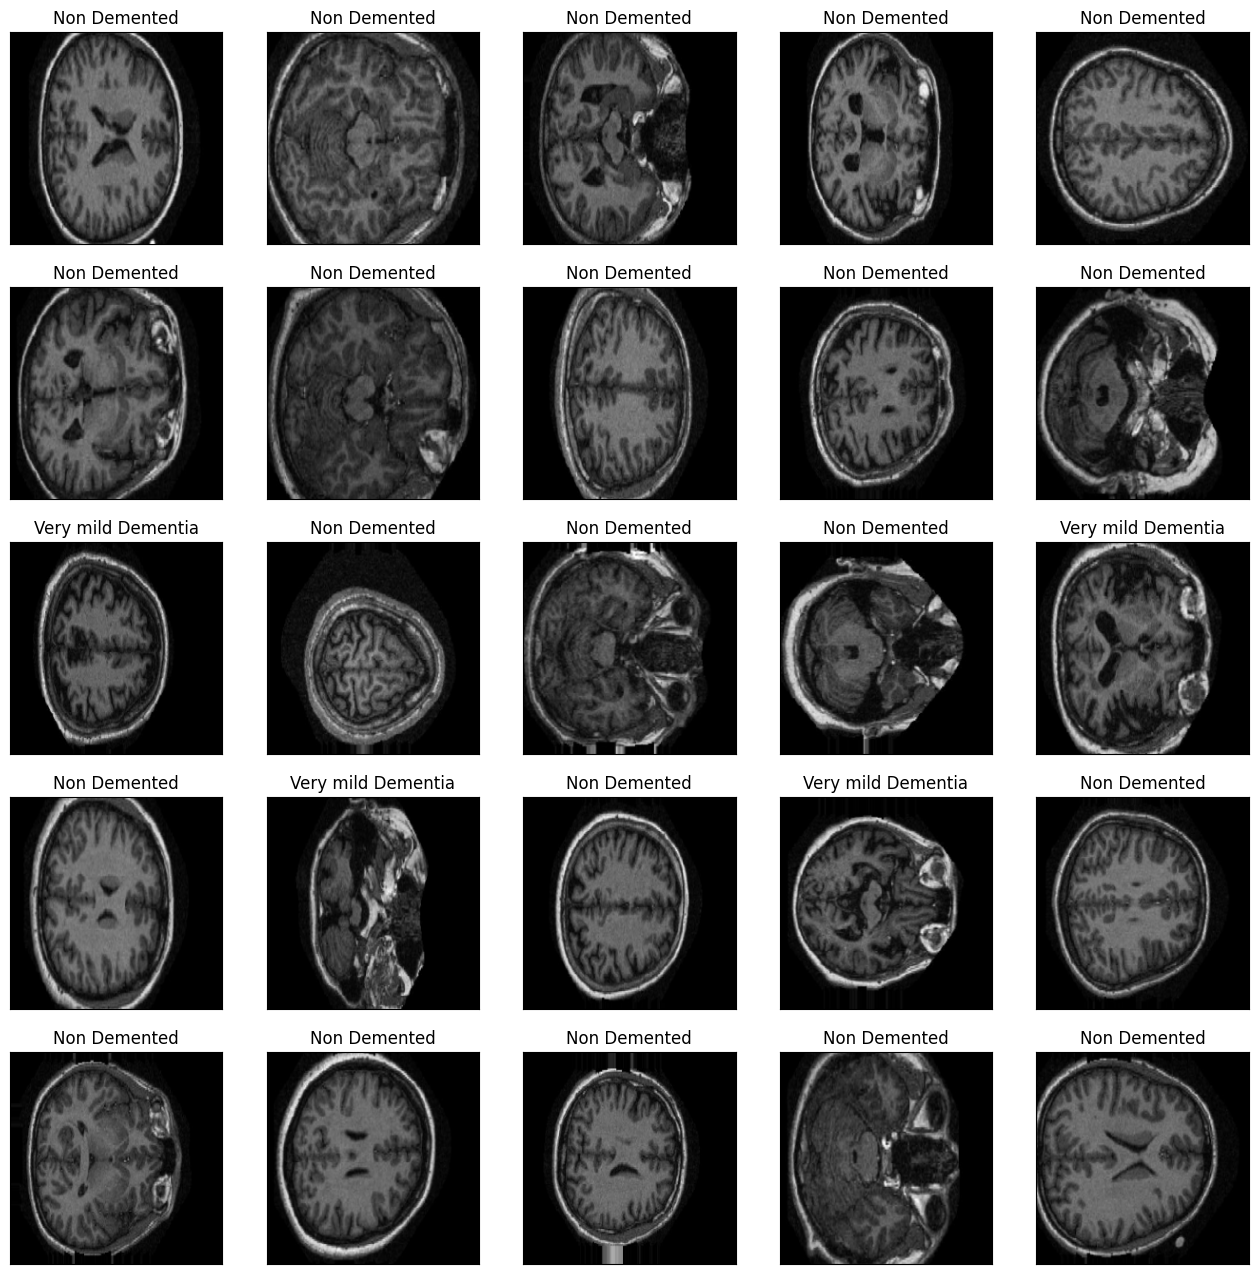

In [22]:
class_name
images, labels = next(train)
plt.figure(figsize=(16,16))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(images[i])
  plt.title(class_name[labels[i].argmax()])




In [23]:
base_model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))

In [24]:
for lay in base_model.layers:
  lay.trainable=False

In [25]:
model=models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation="relu"),
    # layers.Dropout(0.4),
    layers.Dense(4,activation="softmax")
]
)

In [26]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [27]:
history=model.fit(train,epochs=10,validation_data=test)

Epoch 1/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1420s 651ms/step - accuracy: 0.7773 - loss: 0.6648 - val_accuracy: 0.7736 - val_loss: 0.6826
Epoch 2/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1294s 599ms/step - accuracy: 0.7775 - loss: 0.6447 - val_accuracy: 0.7786 - val_loss: 0.6638
Epoch 3/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1317s 610ms/step - accuracy: 0.7776 - loss: 0.6309 - val_accuracy: 0.7777 - val_loss: 0.6889
Epoch 4/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1337s 618ms/step - accuracy: 0.7778 - loss: 0.6245 - val_accuracy: 0.7777 - val_loss: 0.6464
Epoch 5/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1271s 588ms/step - accuracy: 0.7777 - loss: 0.6143 - val_accuracy: 0.7775 - val_loss: 0.6389
Epoch 6/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1266s 586ms/step - accuracy: 0.7778 - loss: 0.6103 - val_accuracy: 0.7776 - val_loss: 0.6498
Epoch 7/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1265s 585ms/step - accuracy: 0.7779 - loss: 0.6034 - val_accuracy: 0.7735 - val_loss: 0.6434
Epoch 8/10
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1268s 587ms/s

In [35]:
acc , loss =model .evaluate(test)
print("accuracy : ",acc)
print("loss : ",loss)

541/541 ━━━━━━━━━━━━━━━━━━━━ 251s 464ms/step - accuracy: 0.7776 - loss: 0.6542
accuracy :  0.6541872620582581
loss :  0.7776235342025757


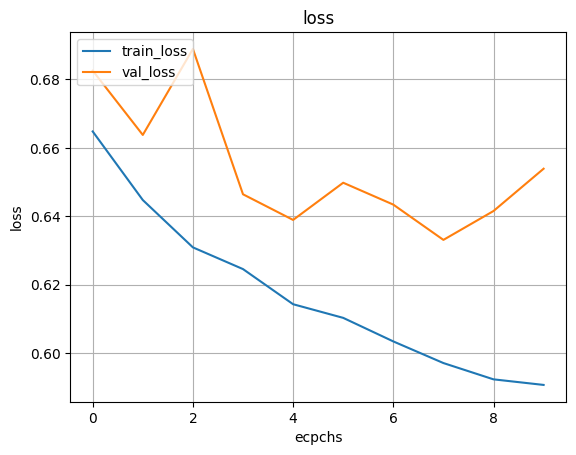

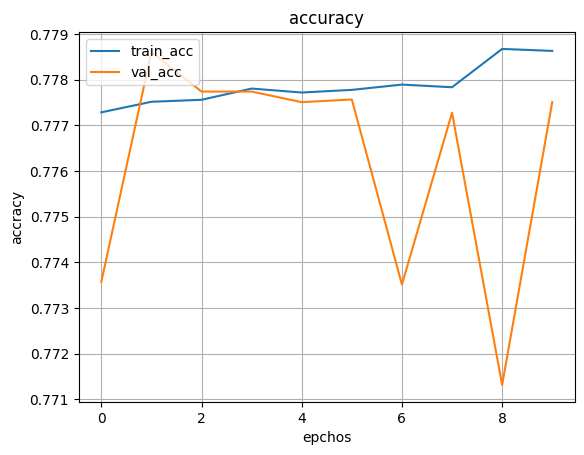

In [32]:
plt.figure()
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history.history["accuracy"],label="train_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [33]:
for lay in model.layers:
  lay.trainable=True


In [ ]:
model.compile(
    optimizer="adam",
    loss="categoricale_crossentropy",
    matrics=["accuracy"]
)

In [34]:
history_fine=model.fit(train,epochs=5,valdiation_data=test)

TypeError: TensorFlowTrainer.fit() got an unexpected keyword argument 'valdiation_data'

In [ ]:
acc_fine,loss_fine=model.evaluate(test)

In [29]:
pred=model.predict(test)

541/541 ━━━━━━━━━━━━━━━━━━━━ 256s 466ms/step


In [30]:
pred=np.argmax(pred,axis=1)

TypeError: 'list' object is not callable

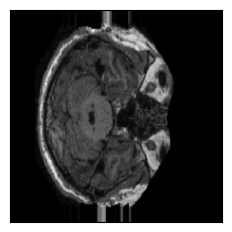

In [36]:
image,label=next(test)
plt.figure(figsize=(16,16))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(image[i])
  plt.xticks([])
  plt.yticks([])
  plt.title(class_name([label[i].argmax()])


In [ ]:
print(classification_report(train,test))